# Reproducibility Notebook: Microwave Component Thermalization in cQED

This notebook reproduces the main results for the study of hot microwave components in a dispersive cQED platform. It is written to support two workflows:

1. Full reproduction: rerun the four simulation thrusts and the validation checks with tunable parameters exposed below.
2. Fast inspection: load the saved JSON artifacts and figures that were already generated in the study directory.

The quantum model resolves effective bath occupation, qubit heating, dephasing, multimode back-action, and intrinsic Lindblad response times. It does **not** model macroscopic thermal transport, boundary resistance, or component heat-flow delays; those must be coupled in as a separate thermal layer.


In [1]:
from __future__ import annotations

import json
import sys
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def locate_scripts_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "scripts",
        Path.cwd() / "studies" / "microwave_component_thermalization_cqed" / "scripts",
    ]
    for candidate in candidates:
        if (candidate / "run_study.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the study scripts directory from the current working directory.")


SCRIPTS_DIR = locate_scripts_dir()
STUDY_ROOT = SCRIPTS_DIR.parent
REPO_ROOT = STUDY_ROOT.parent.parent
DATA_DIR = STUDY_ROOT / "data"
ARTIFACTS_DIR = STUDY_ROOT / "artifacts"
FIGURES_DIR = STUDY_ROOT / "figures"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from common import MultimodeStudyConfig, SingleModeStudyConfig  # noqa: E402
from run_study import run_full_study  # noqa: E402
from validate_results import run_validation  # noqa: E402


def load_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


print(f"Scripts directory: {SCRIPTS_DIR}")
print(f"Study root:        {STUDY_ROOT}")


Scripts directory: C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\microwave_component_thermalization_cqed\scripts
Study root:        C:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\microwave_component_thermalization_cqed


In [2]:
# Tunable parameters for end-to-end reruns.
# Set RUN_FULL_REPRODUCTION = False if you only want to inspect the saved artifacts.

RUN_FULL_REPRODUCTION = True
SAVE_OUTPUTS = True

single_config = replace(
    SingleModeStudyConfig(),
    n_cav_steady=30,
    n_cav_dynamic=12,
    n_tr=3,
    temperature_grid=(0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30, 0.50, 1.0, 2.0),
    dephasing_temperatures=(0.03, 0.05, 0.07, 0.10, 0.15, 0.20, 0.30, 0.50),
    cold_temperature=0.05,
    transient_temperatures=(0.20, 0.50),
    coherence_target=20.0e-6,
)

multimode_config = replace(
    MultimodeStudyConfig(),
    n_readout=6,
    n_storage=6,
    hot_storage_temperature=0.35,
    cold_readout_temperature=0.05,
    detuning_grid_mhz=(-240.0, -180.0, -120.0, -60.0, 0.0, 60.0, 120.0, 180.0, 240.0),
    coupling_grid_mhz=(0.0, 1.5, 3.0, 4.5, 6.0, 7.5, 9.0, 10.5, 12.0),
)

print("Single-mode config:", single_config)
print("Multimode config:", multimode_config)


Single-mode config: SingleModeStudyConfig(omega_q=32672563597.333847, omega_r=43982297150.2571, alpha=-1382300767.579509, chi=-1570796.3267948965, exchange_g=188495559.21538758, kappa_readout=6666666.666666667, t1_qubit=6e-05, tphi_qubit=0.00012, n_cav_steady=30, n_cav_dynamic=12, n_tr=3, temperature_grid=(0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0, 2.0), dephasing_temperatures=(0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3, 0.5), cold_temperature=0.05, transient_temperatures=(0.2, 0.5), coherence_target=2e-05)
Multimode config: MultimodeStudyConfig(omega_q=32672563597.333847, omega_r=43668137884.898125, omega_storage_center=45238934211.69302, alpha=-1382300767.579509, chi_r=-1570796.3267948965, chi_s=-502654.82457436697, qubit_readout_exchange=188495559.21538758, kappa_readout=5555555.555555556, kappa_storage=8333333.333333334, kappa_storage_sensitivity_ns=(300.0, 120.0, 60.0), n_tr=3, n_readout=6, n_storage=6, hot_storage_temperature=0.35, cold_readout_temperature=0.05, detuning_grid_mh

In [3]:
if RUN_FULL_REPRODUCTION:
    study_results = run_full_study(single_config=single_config, multimode_config=multimode_config, save_outputs=SAVE_OUTPUTS)
    validation_results = run_validation(single=single_config, multi=multimode_config, save_output=SAVE_OUTPUTS)
else:
    study_results = None
    validation_results = None

summary = load_json(DATA_DIR / "study_summary.json")
thermometer = load_json(ARTIFACTS_DIR / "thermometer_summary.json")
dephasing = load_json(ARTIFACTS_DIR / "dephasing_summary.json")
multimode = load_json(ARTIFACTS_DIR / "multimode_summary.json")
transient = load_json(ARTIFACTS_DIR / "transient_summary.json")
validation = load_json(ARTIFACTS_DIR / "validation_summary.json")

print(json.dumps(summary, indent=2))
print("All validation checks passed:", validation["passed_all"])


{
  "thermometer": {
    "lowest_temperature_with_qubit_excitation_above_1e-4": 0.05,
    "temperature_where_readout_penalty_drops_below_0p9": 0.15,
    "temperature_where_spectroscopy_width_exceeds_0p1_MHz": 0.2
  },
  "dephasing": {
    "tolerable_temperature_K": 0.1,
    "lowest_t2_us": 0.4471393911307599
  },
  "multimode": {
    "safe_fraction": 0.1111111111111111,
    "most_dangerous_point": {
      "detuning_MHz": -240.0,
      "coupling_MHz": 12.0,
      "qubit_excited_population": 0.16743152214318577
    }
  },
  "transient": {
    "0.20 K": {
      "cavity_response_tau_us": 0.14999992281241634,
      "qubit_response_tau_us": 0.2128749765590848
    },
    "0.50 K": {
      "cavity_response_tau_us": 0.14878258321782153,
      "qubit_response_tau_us": 0.08891516982301348
    }
  },
  "figure_stems": [
    "thermometer_calibration_curves",
    "dephasing_and_coherence_limits",
    "multimode_heating_maps",
    "transient_thermal_step_response"
  ]
}
All validation checks passed: 

In [4]:
selected_temperatures = [0.05, 0.10, 0.20, 0.50, 2.0]
temperature_to_index = {round(temp, 2): index for index, temp in enumerate(thermometer["temperatures_K"])}

print("Thermometer calibration points")
for temperature in selected_temperatures:
    index = temperature_to_index[round(temperature, 2)]
    print(
        f"T = {temperature:>4.2f} K | "
        f"n_th = {thermometer['nth_values'][index]:>7.4f} | "
        f"n_cav = {thermometer['dispersive_cavity_occupation'][index]:>7.4f} | "
        f"P_e = {thermometer['dressed_qubit_excited_population'][index]:>7.4f} | "
        f"width = {thermometer['spectroscopy_width_MHz'][index]:>6.3f} MHz"
    )

print()
print("Dephasing checkpoints")
for temperature in [0.03, 0.05, 0.07, 0.10, 0.15, 0.20]:
    index = dephasing["temperatures_K"].index(temperature)
    print(
        f"T = {temperature:>4.2f} K | "
        f"gamma_phi = {dephasing['gamma_pure_per_s'][index]:>10.1f} 1/s | "
        f"gamma_up = {dephasing['gamma_up_per_s'][index]:>10.1f} 1/s | "
        f"T2 = {1.0e6 * dephasing['t2_total_s'][index]:>7.2f} us"
    )

print()
danger = summary["multimode"]["most_dangerous_point"]
print("Multimode safe fraction:", summary["multimode"]["safe_fraction"])
print("Most dangerous multimode point:", danger)

print()
for key, value in summary["transient"].items():
    print(
        f"{key}: cavity tau = {value['cavity_response_tau_us']:.3f} us, "
        f"qubit tau = {value['qubit_response_tau_us']:.3f} us"
    )


Thermometer calibration points
T = 0.05 K | n_th =  0.0012 | n_cav =  0.0012 | P_e =  0.0012 | width =  0.009 MHz
T = 0.10 K | n_th =  0.0360 | n_cav =  0.0360 | P_e =  0.0335 | width =  0.048 MHz
T = 0.20 K | n_th =  0.2291 | n_cav =  0.2291 | P_e =  0.1527 | width =  0.133 MHz
T = 0.50 K | n_th =  1.0439 | n_cav =  1.0439 | P_e =  0.2903 | width =  0.365 MHz
T = 2.00 K | n_th =  5.4673 | n_cav =  5.2717 | P_e =  0.3315 | width =  1.357 MHz

Dephasing checkpoints
T = 0.03 K | gamma_phi =     7599.8 1/s | gamma_up =       45.6 1/s | T2 =  131.19 us
T = 0.05 K | gamma_phi =     8023.0 1/s | gamma_up =     4027.6 1/s | T2 =   99.63 us
T = 0.07 K | gamma_phi =    10550.3 1/s | gamma_up =    27565.6 1/s | T2 =   41.10 us
T = 0.10 K | gamma_phi =    20665.8 1/s | gamma_up =   118069.7 1/s | T2 =   12.55 us
T = 0.15 K | gamma_phi =    53266.0 1/s | gamma_up =   381649.0 1/s | T2 =    4.10 us
T = 0.20 K | gamma_phi =   100756.9 1/s | gamma_up =   724611.9 1/s | T2 =    2.16 us

Multimode safe

In [5]:
print("Validation audit")
for check in validation["checks"]:
    status = "PASS" if check["passed"] else "FAIL"
    print(f"[{status}] {check['name']}: {check['criterion']}")


Validation audit
[PASS] zero_temperature_limit: n_c < 1e-8 and p_e < 1e-8
[PASS] bose_consistency_0p20K: relative error < 1e-3
[PASS] thermometry_truncation_2K: relative difference < 0.03
[PASS] dephasing_truncation_0p20K: relative difference < 1e-3
[PASS] analytic_dephasing_scaling_low_temperature: relative error < 3.0
[PASS] multimode_weak_coupling_limit: relative difference < 0.1
[PASS] multimode_truncation_representative_point: both relative differences < 0.03


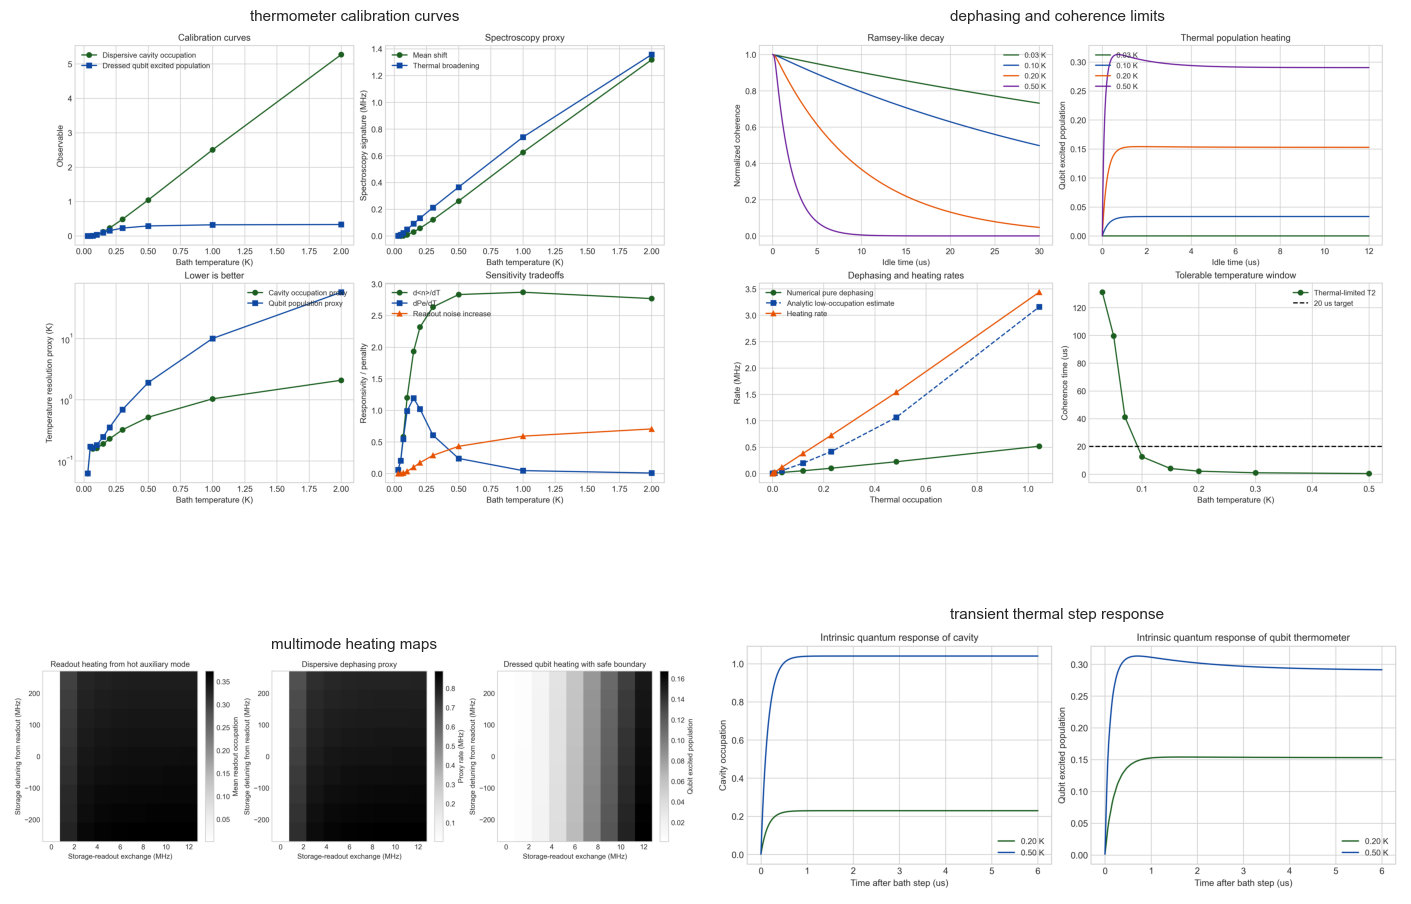

In [6]:
figure_stems = summary["figure_stems"]
figure, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

for axis, stem in zip(axes.ravel(), figure_stems):
    image = plt.imread(FIGURES_DIR / f"{stem}.png")
    axis.imshow(image)
    axis.set_title(stem.replace("_", " "))
    axis.axis("off")

plt.show()


## How to extend this notebook

- Change the truncations, temperature grids, or safe-regime thresholds in the parameter cell and rerun the notebook.
- Replace the representative multimode frequencies, linewidths, or couplings with measured device values once those are available.
- Couple a separate thermal RC or finite-element model into the notebook by generating a time-dependent effective bath occupation and feeding that into the existing cQED layer.
